In [1]:
# ══════════════════════════════════════════════════════════════
# XGBOOST - Student Dropdown Prediction
# ══════════════════════════════════════════════════════════════
# Algorithm: XGBoost Classifier
# Description: Predicting student dropdown using XGBoost algorithm.
# Dataset: OULAD - Open University Learning Analytics Dataset
# Author: Bandara H.M.N.T - IT22251664

# Imprt Data Handling Libraries
import pandas as pd
import numpy as np

# Import XGBoost Classifier
from xgboost import XGBClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ══════════════════════════════════════════════════════════════
# LOAD PROCESSED DATA
# ══════════════════════════════════════════════════════════════

#Load Training Data
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()  # Convert to Series

#Load Testing Data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()  # Convert to Series

#Confirm data shapes
print("=== Data loaded successfully! ===")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")

#Confirm class balance in training data
print("\n=== Class Distribution in Training Data ===")
print(y_train.value_counts())
print()
print("Non-dropout (0):", y_train.value_counts()[0])
print("Dropout (1):", y_train.value_counts()[1])
print()

#Show feature names
print("=== Feature Names ===")
print(X_train.columns.tolist())

print("\nData loading and initial exploration completed successfully! ready for XGBoost modeling.")

=== Data loaded successfully! ===
Training Features Shape: (27532, 14)
Testing Features Shape: (6519, 14)
Training Target Shape: (27532,)
Testing Target Shape: (6519,)

=== Class Distribution in Training Data ===
dropout
1    13766
0    13766
Name: count, dtype: int64

Non-dropout (0): 13766
Dropout (1): 13766

=== Feature Names ===
['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early']

Data loading and initial exploration completed successfully! ready for XGBoost modeling.


In [ ]:
# ══════════════════════════════════════════════════════════════
# TRAIN XGBOOST MODEL
# ══════════════════════════════════════════════════════════════
# XGBoost uses gradient boosting to build trees sequentially
# Each tree focuses on reducing the errors made by previous trees
# Combines multiple weak learners into a strong predictive model
# Final prediction = weighted sum of all trees

# Initialize XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100,       # Number of trees
    max_depth=5,            # Maximum depth of each tree
    learning_rate=0.1,      # Learning rate
    subsample=0.8,          # Subsample ratio of the training instances
    colsample_bytree=0.8,   # Subsample ratio of columns when constructing each tree
    random_state=42,        # For reproducibility
    eval_metric='logloss'     # Evaluation metric for early stopping
)

print("Training XGBoost Model...")
print()

# Train the model
xgb_model.fit(
    X_train, y_train,
    early_stopping_rounds=10,  # Stop if no improvement after 10 rounds
    eval_set=[(X_test, y_test)],  # Use test set for evaluation during training
    verbose=False  # Suppress training output
)

print("\n XGBoost Model training completed successfully!")

print(f"Number of trees:           {xgb_model.n_estimators}")
print(f"Max depth per tree:        {xgb_model.max_depth}")
print(f"Learning rate:             {xgb_model.learning_rate}")
print(f"Subsample ratio:           {xgb_model.subsample}")
print(f"Feature sampling:          {xgb_model.colsample_bytree}")
print(f"Number of input features:  {xgb_model.n_features_in_}")
print(f"Classes predicted:         {xgb_model.classes_}")

Training XGBoost Model...


 XGBoost Model training completed successfully!
Number of trees:           100
Max depth per tree:        5
Learning rate:             0.1
Subsample ratio:           0.8
Feature sampling:          0.8
Number of input features:  14
Classes predicted:         [0 1]


In [5]:
# ══════════════════════════════════════════════════════════════
# Making Prdeictions on test data
# ══════════════════════════════════════════════════════════════
# Model predicts on unseen test data (6,519 students)

print("Making predictions on test data...")
print()

# Make predictions on test set
y_pred = xgb_model.predict(X_test)

# Predict probabilities
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")
print(f"Predicted classes: {np.unique(y_pred)}")
print(f"Prediction probabilities: {y_pred_proba[:5]}")


Making predictions on test data...

Predictions completed successfully!
Predicted classes: [0 1]
Prediction probabilities: [0.02071087 0.99969363 0.83849716 0.0490975  0.7392018 ]


In [6]:
# = = Model Evaluation Results = =
# Evaluate model performance using various metrics
print("Evaluating model performance...")
print()

print("=== MODEL EVALUATION RESULTS ===")
print()

# Calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

# Print all metrics clearly
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"ROC-AUC:   {roc_auc*100:.2f}%")
print()

# Full classification report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
      target_names=['Non-Dropout (0)', 'Dropout (1)']))

Evaluating model performance...

=== MODEL EVALUATION RESULTS ===

Accuracy:  89.52%
Precision: 91.77%
Recall:    88.06%
F1 Score:  89.87%
ROC-AUC:   96.72%

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Non-Dropout (0)       0.87      0.91      0.89      3077
    Dropout (1)       0.92      0.88      0.90      3442

       accuracy                           0.90      6519
      macro avg       0.89      0.90      0.90      6519
   weighted avg       0.90      0.90      0.90      6519



=== CONFUSION MATRIX VALUES ===
True Negative  (TN): 2805
False Positive (FP): 272
False Negative (FN): 411
True Positive  (TP): 3031



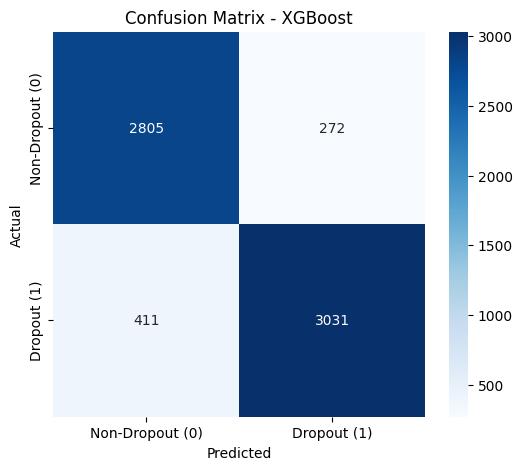

Chart saved to report folder
Total correct predictions:   5836
Total incorrect predictions: 683



In [8]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
# Shows 4 values:
# True Positive  (TP) — predicted dropout,     actually dropout
# True Negative  (TN) — predicted non-dropout, actually non-dropout
# False Positive (FP) — predicted dropout,     actually non-dropout
# False Negative (FN) — predicted non-dropout, actually dropout

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("=== CONFUSION MATRIX VALUES ===")
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive  (TP): {tp}")
print()

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Dropout (0)', 'Dropout (1)'],
            yticklabels=['Non-Dropout (0)', 'Dropout (1)'])

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../report/confusion_matrix_xgboost.png", dpi=300, bbox_inches='tight')

plt.show()
print("Chart saved to report folder")

print(f"Total correct predictions:   {tn + tp}")
print(f"Total incorrect predictions: {fp + fn}")
print()

